In [1]:
import matplotlib

matplotlib.rcParams.update({"legend.fontsize": 14, "legend.handlelength": 2})
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
import pandas as pd

#### Load `uam_system_model` dependencies

In [2]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.utils.visualize import plot_parameters, plot_travel_time


#### Prepare input

| Index | Vertiport | 位置         | 类型       |
| :---: | :-------- | :----------- | :------- |
|   0   | PEK       | 首都国际机场       | Hub      |
|   1   | PKX       | 大兴国际机场       | Hub      |
|   2   | CBD       | 国贸/建外SOHO 附近 | spoke |
|   3   | ZGC       | 中关村创新中心      | spoke |
|   4   | WJ        | 望京SOHO 或酒仙桥  | spoke  |
|   5   | TON       | 通州行政副中心      | spoke |
|   6   | LZC       | 丽泽金融区        | spoke |
|   7   | SLT       | 三里屯/东直门      | spoke |
|   8   | HDX       | 回龙观/天通苑      | spoke |
     


In [3]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters / 1600
    return distance_matrix


import numpy as np
from geopy.distance import geodesic

# 替换坐标
coordinates = np.array(
    [
        (40.08011111321591, 116.58455699194977),  # PEK(Hub)首都国际机场
        (39.50989628232102, 116.41082810590967),  # PKX(Hub)大兴国际机场
        (39.90869214782151, 116.46020394296878),  # CBD 国贸CBD
        (39.98361463750362, 116.31652820219623),  # ZGC 中关村
        (39.99664323970983, 116.47461527394442),  # WJ 望京
        (39.90251382094451, 116.66324391969994),  # TON 通州副中心
        (39.87081734812004, 116.32730571516258),  # LZC 丽泽金融区
        (39.93328920730081, 116.45498348791117),  # SLT 三里屯/东直门
        (40.07097384525619, 116.41200824269246),  # HDX 回龙观/天通苑
    ]
)

distance_matrix = calculate_distances_in_meters(coordinates)

# 替换节点名称
vertiports = ["PEK", "PKX", "CBD", "ZGC", "WJ", "TON", "LZC", "SLT", "HDX"]

# 前两个(Hub)pmf为0，其余七个先假设
vertiport_pmf = np.array([0, 0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5], dtype=float)
vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

# 生成假设的北京数据：根据 LA 的 flight_time_matrix.npy 与 energy_consumption_matrix.npy 线性回归出截距 + 每公里斜率，再生成北京的矩阵
flight_time_matrix = np.load("uam_system_model/data/config/beijing_flight_time_matrix.npy")
energy_consumption_matrix = np.load(
    "uam_system_model/data/config/beijing_energy_consumption_matrix.npy"
)

#### Create instance variable

In [4]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
    path_schedule="uam_system_model/data/PEK-PEX-Schedules20251023.xlsx",
)

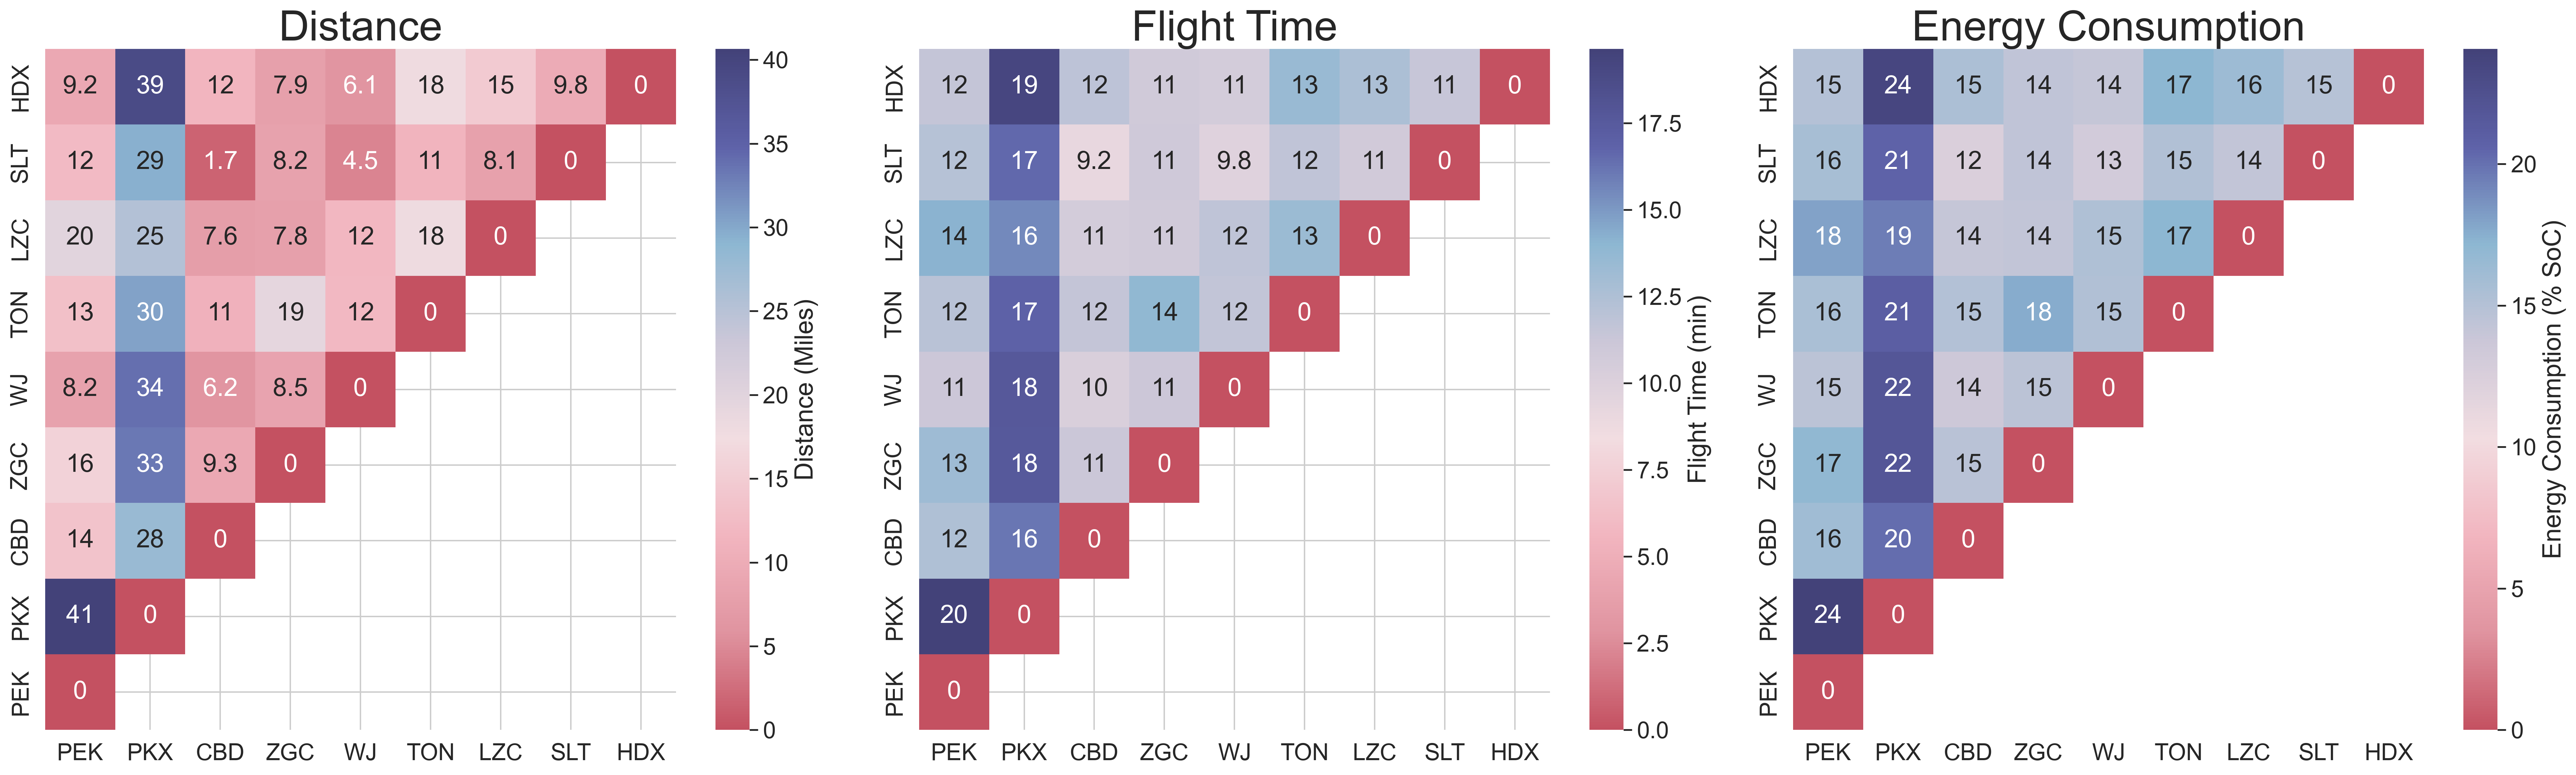

In [5]:
plot_parameters(network);

#### Load demand & visualize

In [6]:
schedule, pax_arrival_times = network.load_demand(
    month=10,
    day=22,
    hub_names=["PEK", "PKX"],
    directional_demand=2500,
    vertiport_pmf=vertiport_pmf,
)

schedule

,schedule,od,num_pax,revenue
0,3.650605,PEK_SLT,4,147.765486
1,5.000000,PEK_HDX,3,82.987187
2,6.528091,WJ_PEK,1,24.728401
3,6.907128,PEK_TON,3,117.186037
4,7.604303,PEK_CBD,4,163.467695
...,...,...,...,...
3747,1437.887423,PKX_TON,1,91.257554
3748,1438.457163,CBD_PKX,1,83.399848
3749,1439.127234,PKX_SLT,4,353.709103
3750,1439.364539,PKX_CBD,3,250.199545


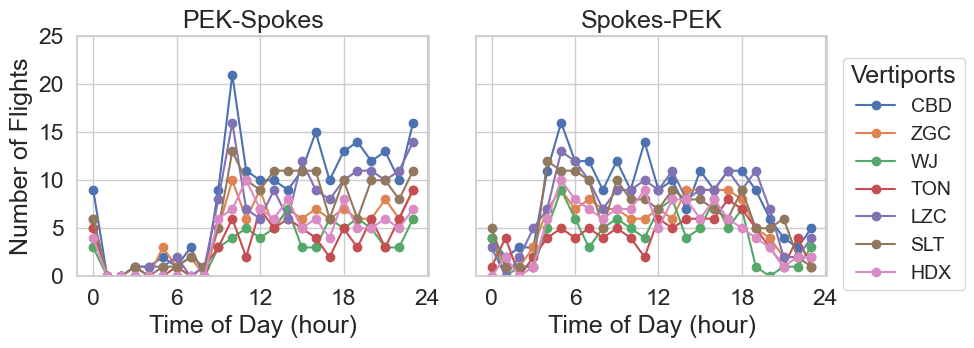

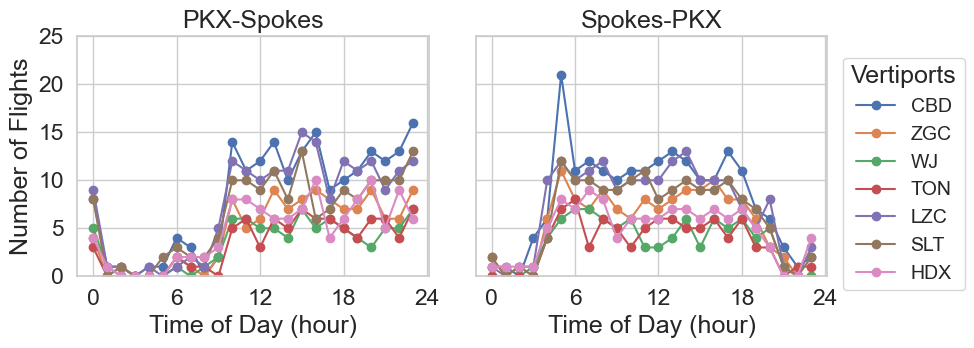

In [11]:
# 看 PEK
fig, ax = network.plot_flight(hub_name="PEK", ylim=(0, 25))
plt.show()

# 看 PKX
fig, ax = network.plot_flight(hub_name="PKX", ylim=(0, 25))
plt.show()


#### Two-vertiport zero-spill (fleet sizing) optimization

In [12]:
from uam_system_model.FleetSizeOp import FleetSizeOptimizer
from uam_system_model.utils.FleetSizeOpSummary import FleetSizeOpSummary

In [13]:
ip = FleetSizeOptimizer(network)
fleetsize, policy = ip.optimize(vertiport_index=4,
                                verbose=True, 
                                optimality_gap=0.05, 
                                n_threads=24)

TypeError: 'numpy.float64' object cannot be interpreted as an integer

In [ ]:
summary = FleetSizeOpSummary(network, policy)

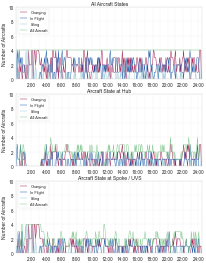

In [ ]:
fig, ax = summary.plot_aircraft_state()
for a in ax:
    a.figure.set_dpi(20)

In [ ]:
summary.get_summary_statistics()

{'fleet_size': 4,
 'total_pads': 7,
 'pads_at_hub': 3,
 'pads_at_spoke': 4,
 'number_of_flights': 238,
 'number_of_repositioning_flights': 52,
 'percentage_repositioning_flights': np.float64(0.2185),
 'energy_consumption_kWh': np.float64(5712.0),
 'TAM': np.float64(3270.65),
 'RAM': np.float64(2556.06)}

#### Run VRP Optimization

In [ ]:
from uam_system_model.FleetOpVRP import FleetOpVRP
from uam_system_model.utils.FleetOpVRPSummary import FleetOpVRPSummary

In [ ]:
import psutil, os
print(f"当前可用内存: {psutil.virtual_memory().available / 1024**3:.2f} GB")

当前可用内存: 1.31 GB


In [ ]:
vrp = FleetOpVRP(StarNetwork=network)
# 没有beta_0_coefficient，设为1
# 内存不够，20改为2
unserved_tours, served_tours = vrp.optimize(15, 3, 0.7, 1, n_processes=2, verbose=True)

INFO - 2025-11-04 03:18:13,204 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - [1] BUILDING SUBTOURS
INFO - 2025-11-04 03:20:20,723 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - [2] SOLVING KNAPSACK PROBLEM
INFO - 2025-11-04 03:20:20,723 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - [2] SOLVING KNAPSACK PROBLEM
INFO - 2025-11-04 03:20:20,888 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - NUMBER OF FLIGHTS BEFORE: 2317 NUMBER OF TOURS AFTER: 2317
INFO - 2025-11-04 03:20:20,890 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - [3] SOLVING THE CLUSTERING/SCHEDULING PROBLEM
INFO - 2025-11-04 03:20:20,888 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - NUMBER OF FLIGHTS BEFORE: 2317 NUMBER OF TOURS AFTER: 2317
INFO - 2025-11-04 03:20:20,890 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - [3] SOLVING THE CLUSTERING/SCHEDULING PROBLEM
100%|██████████| 4636/4636 [15:19<00:00,  5.04it/s] 

INFO - 2025-11-04 03:36:18,347 - FleetOpVRP_M8_D1_V15_MZPT3_MTE0_B01 - NUMBER OF FLIGHTS SELECTED AFTER CLUSTERING: 1509/2317
INFO - 2025-11-04 03:36:18,349 - 

GurobiError: Out of memory

In [ ]:
# The optimization can take a while to solve, attached is a sample solution. The input should be the same as the `served_tours` variable in the previous cell.
served_tours = pd.read_csv("uam_system_model/data/sample_vrp_solution.csv")
summary = FleetOpVRPSummary(
    StarNetwork=network,
    policy=served_tours,
)
summary.get_summary_statistics()

{'fleet_size': 41,
 'total_pads': 73,
 'pads_at_vertiport': {'LAX': 22,
  'DTLA': 11,
  'LGB': 7,
  'WDHL': 6,
  'UVS': 4,
  'ANH': 7,
  'HWD': 7,
  'PSD': 5,
  'BVH': 4},
 'max_takeoff_per_hour': {'LAX': 69,
  'DTLA': 21,
  'LGB': 15,
  'WDHL': 9,
  'UVS': 10,
  'ANH': 16,
  'HWD': 15,
  'PSD': 12,
  'BVH': 11},
 'number_of_aircraft_hours': 420.42,
 'number_of_flights': 2213,
 'number_of_revenue_flights': 1952,
 'number_of_repositioning_flights': 261,
 'percentage_repositioning_flights': 0.1179,
 'energy_consumption_kWh': 37812.5,
 'TAM': 33671.96,
 'RAM': 29986.01,
 'average_load_factor': 0.6036}